In [1]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
import pandas as pd

def find_nearest(array, value):
    array = np.asarray(array)
    idx = (np.abs(array - value)).argmin()
    return idx, array[idx]


In [174]:
file_caII = '/Volumes/ViSP_External/CaII_11Aug2024_Cclass_newcalib.npz'
file_hbeta = '/Volumes/ViSP_External/Hbeta_11Aug2024_Cclass_newcalib.npz'
ViSPcoords = '/Users/coletamburri/Desktop/ViSPcoords_newcalib.npz'


hbeta_low =353
hbeta_core = 470
hbeta_high = 640

caII_low = 480 #570 for first calibration pre March 6
caII_core = 565
caII_high = 690

hepsilon_low = 685
hepsilon_high = 810

nsteps = 91
start = 57 #143 for saved Hbeta spectra
nframes = 10

In [9]:
res_caII = np.load(file_caII)
res_hbeta = np.load(file_hbeta)
dkist_coords = np.load(ViSPcoords)

In [10]:
xarr_caII = dkist_coords['xarr_caII']
yarr_caII = dkist_coords['yarr_caII']

xarr_hbeta = dkist_coords['xarr_hbeta']
yarr_hbeta = dkist_coords['yarr_hbeta']

In [11]:
flare_arr_caII = res_caII['flare']
wave_caII = res_caII['wl']

flare_arr_hbeta = res_hbeta['flare']
wave_hbeta = res_hbeta['wl']

times=res_caII['time'];

In [175]:
bestseeingcaII_red = flare_arr_caII[148:239,caII_high,:]
bestseeingcaII_core = flare_arr_caII[148:239,caII_core,:]
bestseeingcaII_blue = flare_arr_caII[148:239,caII_low,:]

bestseeinghbeta_red = flare_arr_hbeta[148:239,hbeta_high,:]
bestseeinghbeta_core = flare_arr_hbeta[148:239,hbeta_core,:]
bestseeinghbeta_blue = flare_arr_hbeta[148:239,hbeta_low,:]

In [182]:
wave_caII[caII_low]-396.85

np.float64(-0.07899525088612336)

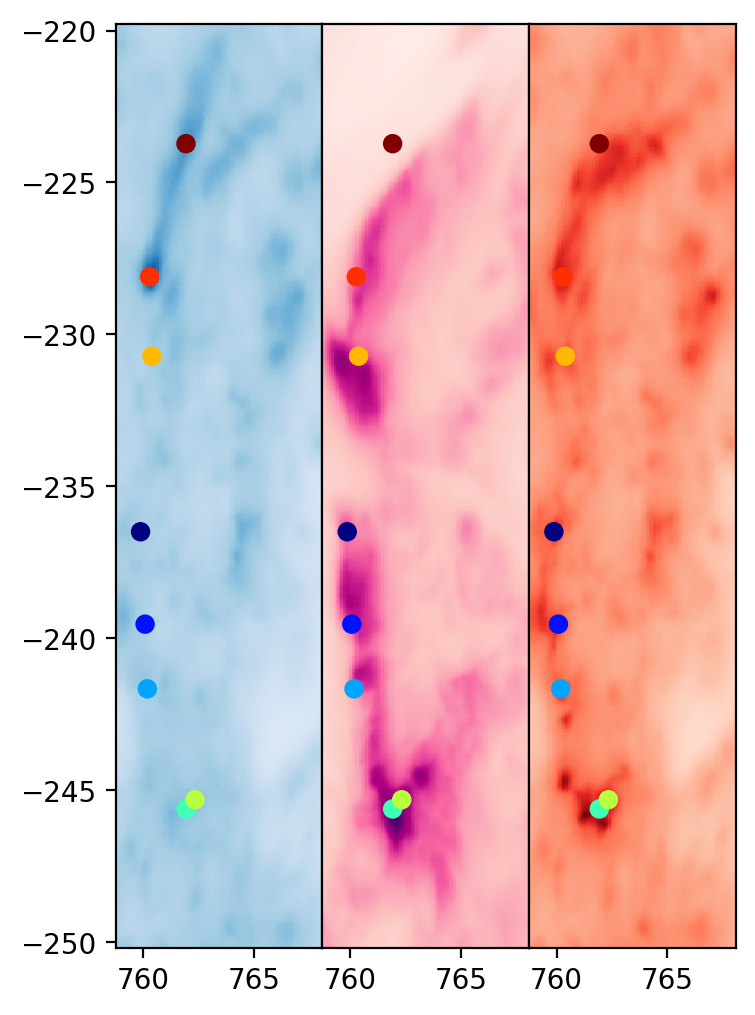

In [194]:
n_points = 8
colors = plt.cm.jet(np.linspace(0,1,n_points))
#region A, region B, region C, Region D1, region D2, region Asymm, region Asymm with red,  region Bkern, region Bblue, region Binit
xsel = [xarr_caII[80],xarr_caII[78],xarr_caII[77],xarr_caII[60],xarr_caII[56],xarr_caII[75],xarr_caII[76],xarr_caII[60]]
ysel = [yarr_caII[1050],yarr_caII[1150],yarr_caII[1220],yarr_caII[1350],yarr_caII[1340],yarr_caII[860],yarr_caII[774],yarr_caII[630]]

fig,ax=plt.subplots(1,3,figsize=(4,6),dpi=200)
ax.flatten()[0].pcolormesh(xarr_caII,yarr_caII,np.transpose(bestseeingcaII_blue),cmap='Blues')

ax.flatten()[0].scatter(xsel,ysel,color=colors)
ax.flatten()[0].set_ylim([yarr_caII[1500],yarr_caII[500]])

ax.flatten()[1].pcolormesh(xarr_caII,yarr_caII,np.transpose(bestseeingcaII_core),cmap='RdPu')
ax.flatten()[1].set_ylim([yarr_caII[1500],yarr_caII[500]])

ax.flatten()[1].scatter(xsel,ysel,color=colors)
ax.flatten()[1].set_yticks([])

ax.flatten()[2].pcolormesh(xarr_caII,yarr_caII,np.transpose(bestseeingcaII_red),cmap='Reds')
ax.flatten()[2].set_ylim([yarr_caII[1500],yarr_caII[500]])

ax.flatten()[2].scatter(xsel,ysel,color=colors)
ax.flatten()[2].set_yticks([])

fig.subplots_adjust(wspace=0)


In [117]:

ls = [80,78,77,60,56,75,76,60]
ms = [1050,1150,1220,1350,1340,860,774,630]

TypeError: unsupported operand type(s) for +: 'int' and 'list'

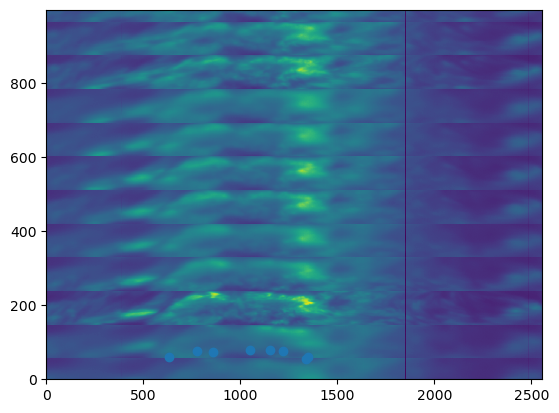

In [116]:
plt.pcolormesh(flare_arr_caII[:,550,:])
plt.scatter(ms,ls)

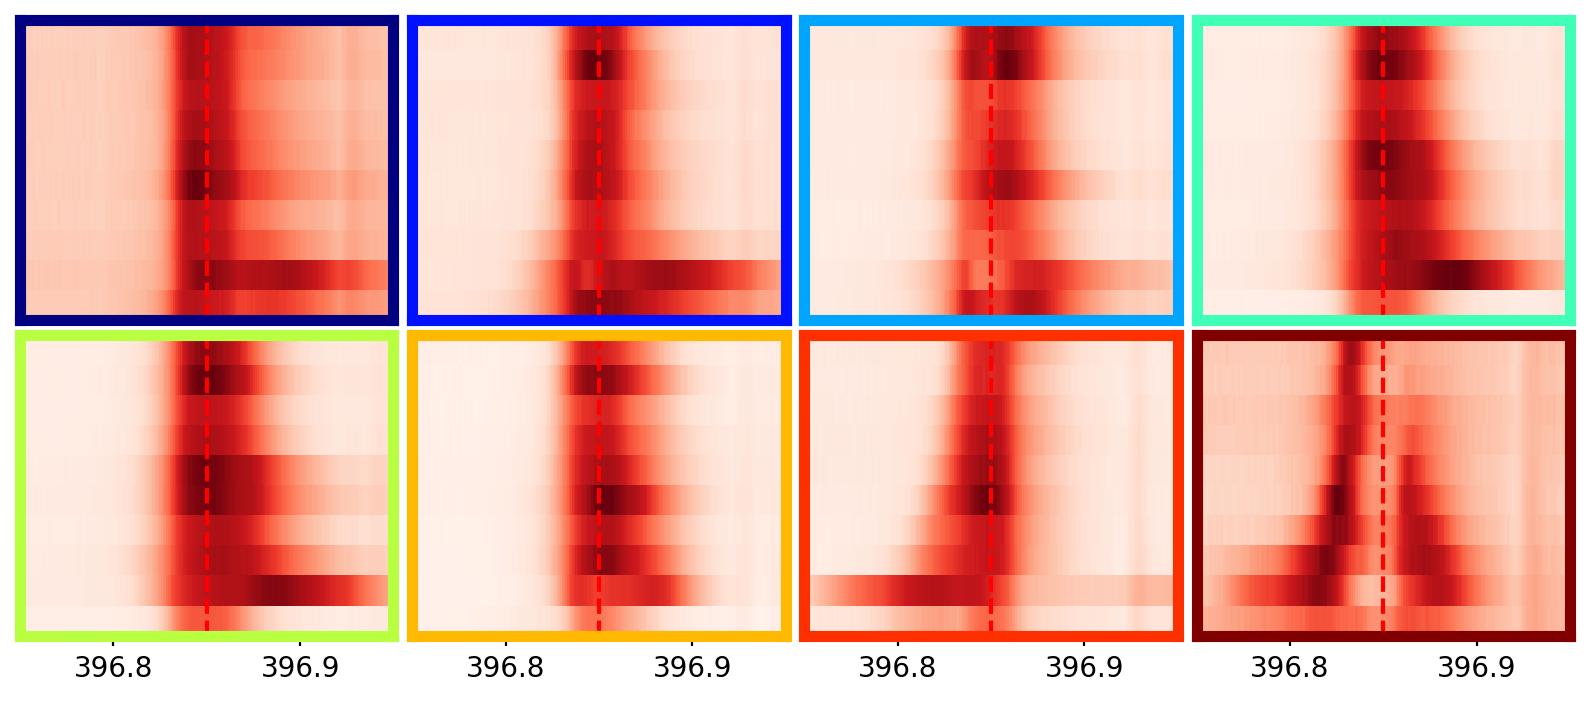

In [185]:
fig,ax=plt.subplots(2,4,figsize=(10,4),dpi=200)

for j in range(len(ls)):
    l=ls[j]
    m=ms[j]
    caiipcolor =[]
    for i in np.arange(0,10*91,91):
        if i == 91:
            caiipcolor.append(flare_arr_caII[l+i+57,:,m]/1.5)

        else:
            caiipcolor.append(flare_arr_caII[l+i+57,:,m])
    ax.flatten()[j].pcolormesh(wave_caII,np.arange(0,10*91,91),caiipcolor,cmap='Reds')
    ax.flatten()[j].set_xlim([396.75,396.95])
    ax.flatten()[j].set_yticks([])
    ax.flatten()[j].set_xticks([396.8,396.9])
    ax.flatten()[j].axvline(396.85,c='red',linestyle='dashed')
    if j < 4:
       ax.flatten()[j].set_xticks([]) 
    for spine in ax.flatten()[j].spines.values():
        spine.set_color(colors[j])
        spine.set_linewidth(4) # Optional: make it thicker

    ax.flatten()[j].xaxis.get_major_formatter().set_useOffset(False)

fig.subplots_adjust(wspace=0.05)
fig.subplots_adjust(hspace=0.05)

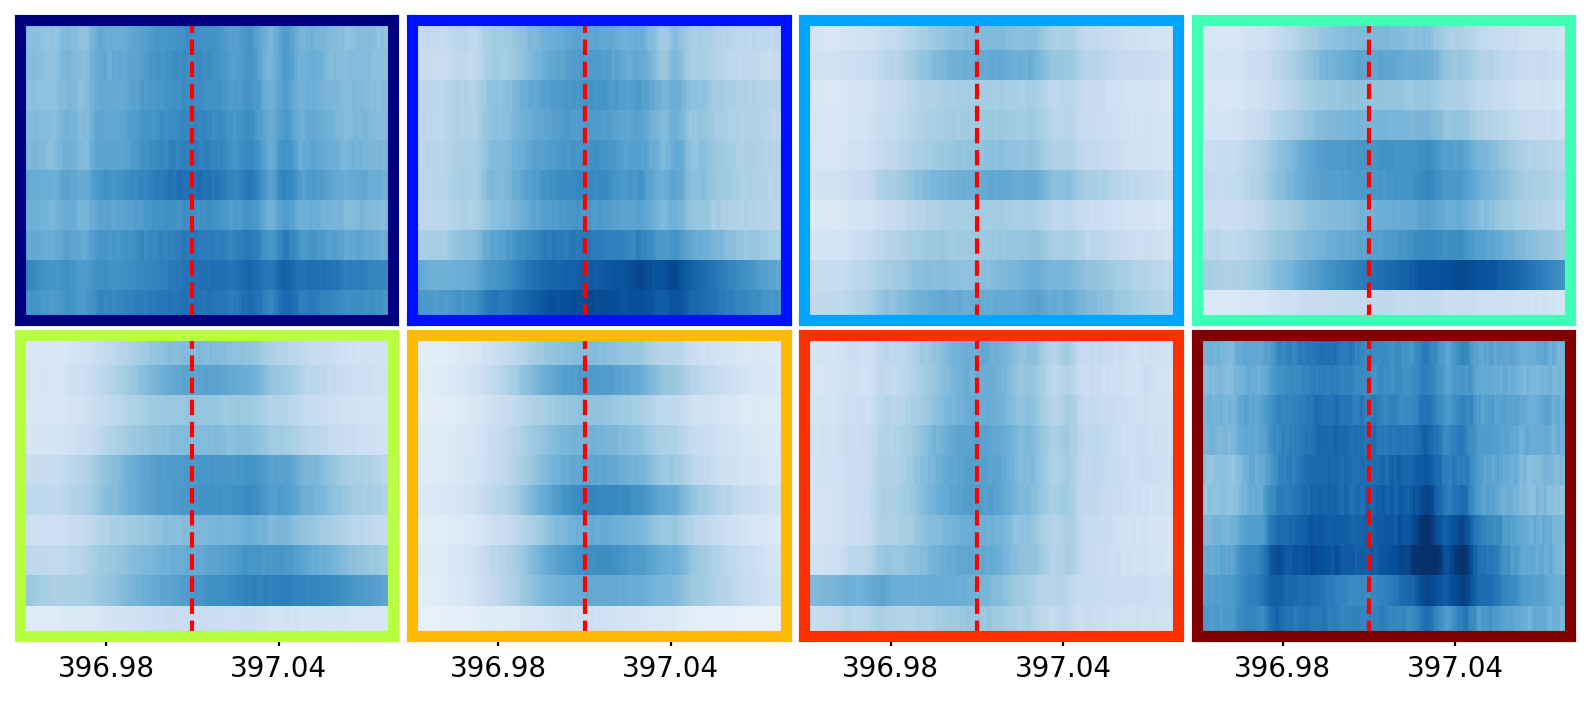

In [187]:
fig,ax=plt.subplots(2,4,figsize=(10,4),dpi=200)

for j in range(len(ls)):
    l=ls[j]
    m=ms[j]
    caiipcolor =[]
    for i in np.arange(0,10*91,91):
        if i == 91:
            caiipcolor.append(flare_arr_caII[l+i+57,:,m]/2)

        else:
            caiipcolor.append(flare_arr_caII[l+i+57,:,m])
    ax.flatten()[j].pcolormesh(wave_caII,np.arange(0,10*91,91),caiipcolor,cmap='Blues',vmax=2.5*flare_arr_caII[l+i+57,750,m])
    ax.flatten()[j].set_xlim([396.95,397.08])
    ax.flatten()[j].set_yticks([])
    ax.flatten()[j].set_xticks([396.98,397.04])
    ax.flatten()[j].axvline(397.01,c='red',linestyle='dashed')
    if j < 4:
       ax.flatten()[j].set_xticks([]) 
    for spine in ax.flatten()[j].spines.values():
        spine.set_color(colors[j])
        spine.set_linewidth(4) # Optional: make it thicker

    ax.flatten()[j].xaxis.get_major_formatter().set_useOffset(False)

fig.subplots_adjust(wspace=0.05)
fig.subplots_adjust(hspace=0.05)

In [158]:
wave_hbeta

array([485.61997006, 485.62107077, 485.62217148, 485.62327219,
       485.6243729 , 485.62547361, 485.62657431, 485.62767502,
       485.62877573, 485.62987644, 485.63097715, 485.63207786,
       485.63317857, 485.63427928, 485.63537999, 485.6364807 ,
       485.6375814 , 485.63868211, 485.63978282, 485.64088353,
       485.64198424, 485.64308495, 485.64418566, 485.64528637,
       485.64638708, 485.64748779, 485.64858849, 485.6496892 ,
       485.65078991, 485.65189062, 485.65299133, 485.65409204,
       485.65519275, 485.65629346, 485.65739417, 485.65849487,
       485.65959558, 485.66069629, 485.661797  , 485.66289771,
       485.66399842, 485.66509913, 485.66619984, 485.66730055,
       485.66840126, 485.66950196, 485.67060267, 485.67170338,
       485.67280409, 485.6739048 , 485.67500551, 485.67610622,
       485.67720693, 485.67830764, 485.67940834, 485.68050905,
       485.68160976, 485.68271047, 485.68381118, 485.68491189,
       485.6860126 , 485.68711331, 485.68821402, 485.68

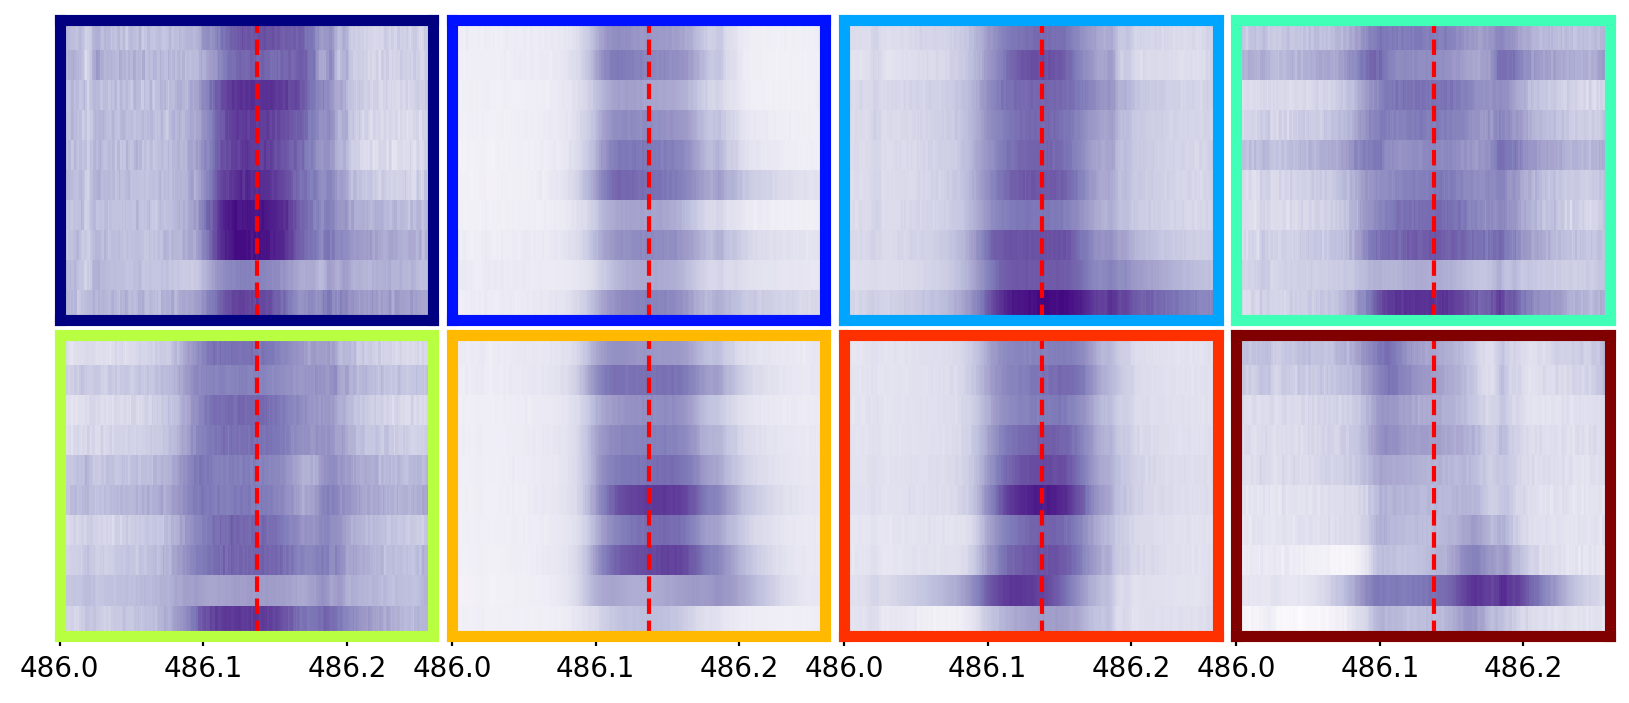

In [188]:
fig,ax=plt.subplots(2,4,figsize=(10,4),dpi=200)

for j in range(len(ls)):
    l=ls[j]
    m=ms[j]
    hbetapcolor =[]
    for i in np.arange(0,10*91,91):
        if i == 91:
            hbetapcolor.append(flare_arr_hbeta[l+i+57,:,m]/2)

        else:
            hbetapcolor.append(flare_arr_hbeta[l+i+57,:,m])
    ax.flatten()[j].pcolormesh(wave_hbeta,np.arange(0,10*91,91),hbetapcolor,cmap='Purples',vmax=2*flare_arr_hbeta[l+i+57,450,m])
    ax.flatten()[j].set_xlim([486,486.26])
    ax.flatten()[j].set_yticks([])
    #ax.flatten()[j].set_xticks([396.820,396.880])
    ax.flatten()[j].axvline(486.1375,c='red',linestyle='dashed')
    if j < 4:
       ax.flatten()[j].set_xticks([]) 
    for spine in ax.flatten()[j].spines.values():
        spine.set_color(colors[j])
        spine.set_linewidth(4) # Optional: make it thicker

fig.subplots_adjust(wspace=0.05)
fig.subplots_adjust(hspace=0.05)

In [56]:
n_points = 10
colors = plt.cm.jet(np.linspace(0,1,n_points))


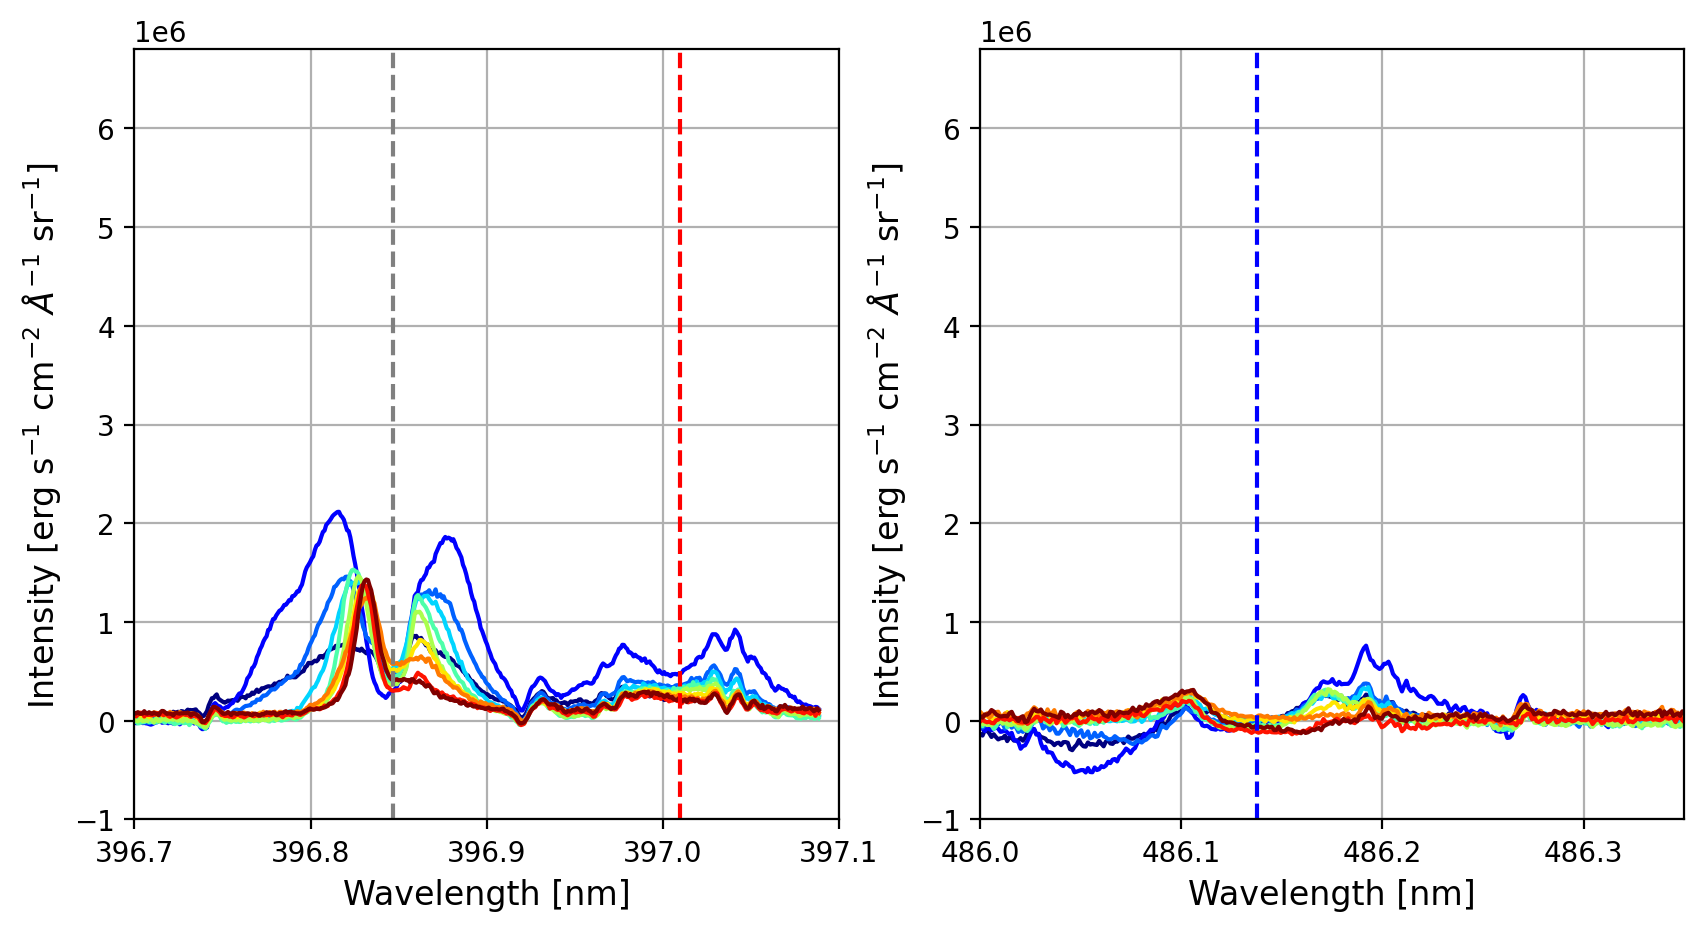

In [89]:
i = 9

xch = xsel[i]
ych = ysel[i]
#plot with ViSP time series

# ID VISP coord

caII_xc = xarr_caII[xch]
caII_yc = yarr_caII[ych]

#get vbi blue coordinates
xchhbeta, hb_xc = find_nearest(xarr_hbeta,caII_xc)
ychhbeta, hb_yc = find_nearest(yarr_hbeta,caII_yc)

fig,ax=plt.subplots(1,2,figsize=(10,5),dpi=200)

for j in range(-1,9,1):
    ax.flatten()[0].plot(wave_caII,flare_arr_caII[148+xch+91*j,:,ych],color=colors[j+1])
    ax.flatten()[1].plot(wave_hbeta,flare_arr_hbeta[148+xchhbeta+91*j,:,ychhbeta],color=colors[j+1])

ax.flatten()[0].set_xlim([396.7,397.08])
ax.flatten()[1].set_xlim([486.0,486.35])
ax.flatten()[0].set_ylim([-1e6,6.8e6])
ax.flatten()[1].set_ylim([-1e6,6.8e6])

ax.flatten()[0].axvline(396.847,linestyle='dashed',color='grey')
ax.flatten()[0].axvline(397.01,linestyle='dashed',color='red')
ax.flatten()[1].axvline(486.1375,linestyle='dashed',color='blue')




ax.flatten()[0].set_xlabel('Wavelength [nm]',fontsize=12)
ax.flatten()[0].set_ylabel(r'Intensity [erg s$^{-1}$ cm$^{-2}$ $\AA^{-1}$ sr$^{-1}$]',fontsize=12)

ax.flatten()[1].set_xlabel('Wavelength [nm]',fontsize=12)
ax.flatten()[1].set_ylabel(r'Intensity [erg s$^{-1}$ cm$^{-2}$ $\AA^{-1}$ sr$^{-1}$]',fontsize=12)

ax.flatten()[0].grid('on')
ax.flatten()[1].grid('off')

ax.flatten()[0].set_xticks([396.7,396.8,396.9,397,397.1])
ax.flatten()[1].set_xticks([486,486.1,486.2,486.3])





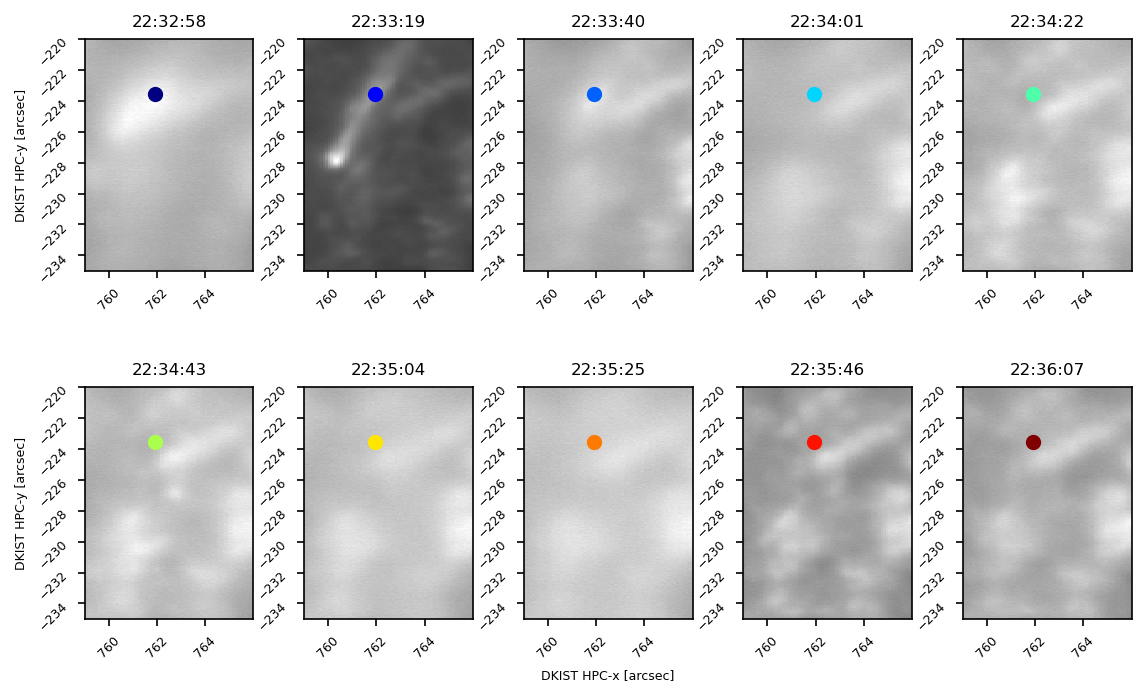

In [79]:
fig,ax=plt.subplots(2,5,figsize=(8,5),dpi=150)

if i == 3 or i == 4:
    ylo=-250
    yhi=-240
    xlo=759
    xhi=766

if i==0 or i ==1 or i==2 or i==5 or i ==6:
    ylo=-245
    yhi=-235
    xlo=759
    xhi=766

if i>6:
    ylo=-235
    yhi=-220
    xlo=759
    xhi=766

for j in range(10):
    if i<8:
        ax.flatten()[j].pcolormesh(xarr_caII[:-1],yarr_caII,np.transpose(flare_arr_caII[57+(91*j):56+(91*(j+1)),caII_high,:]),cmap='grey',alpha=1)
    else:
        ax.flatten()[j].pcolormesh(xarr_caII[:-1],yarr_caII,np.transpose(flare_arr_caII[57+(91*j):56+(91*(j+1)),caII_low,:]),cmap='grey',alpha=1)
   
    #xsel=xsel-lower_threshold+xlo

    ax.flatten()[j].scatter(caII_xc,caII_yc,40,color=colors[j],alpha=1,marker='o')

    #ax.flatten()[i].set_ylim([yhi,ylo])
    ax.flatten()[j].set_ylim([ylo,yhi])
    ax.flatten()[j].set_xlim([xlo,xhi])
    ax.flatten()[j].tick_params(axis='x', labelrotation=45)
    ax.flatten()[j].tick_params(axis='y', labelrotation=45)
    
    ax.flatten()[j].tick_params(axis='x',labelsize=6)
    ax.flatten()[j].set_xticks([760,762,764])
    ax.flatten()[j].tick_params(axis='y',labelsize=6)
    ax.flatten()[j].set_title(times[57+91*j][11:19],fontsize=8)
    #ax.flatten()[i].set_xticks([760,763,766])
ax.flatten()[0].set_ylabel('DKIST HPC-y [arcsec]',fontsize=6)
ax.flatten()[5].set_ylabel('DKIST HPC-y [arcsec]',fontsize=6)

ax.flatten()[7].set_xlabel('DKIST HPC-x [arcsec]',fontsize=6)
fig.tight_layout(pad=2.0) 
fig.subplots_adjust(hspace=0.5,wspace=0.3)

In [39]:
nonflare=np.load('/Users/coletamburri/Desktop/nonflareHbeta.npz')

In [40]:
nonflare


NpzFile '/Users/coletamburri/Desktop/nonflareHbeta.npz' with keys: nonflare, wl

In [41]:
nf = nonflare['nonflare']

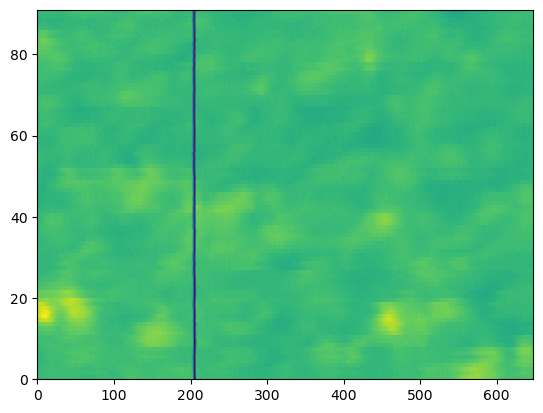

In [42]:
plt.pcolormesh(nf[:,700,:])

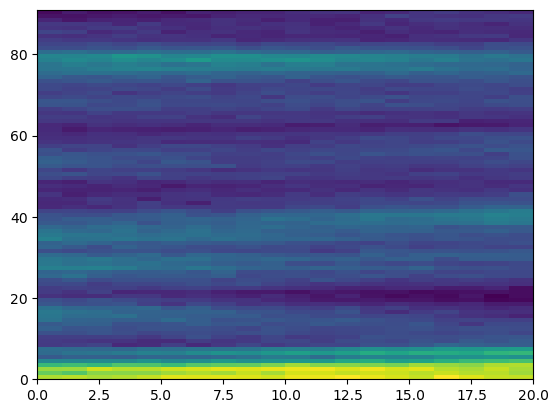

In [43]:
plt.pcolormesh(nf[:,700,560:580])

In [46]:
stavg1 = np.mean(np.mean(nf,axis=0),1)

In [47]:
stavg2 = np.mean(np.mean(nf[:,:,230:],axis=0),1)

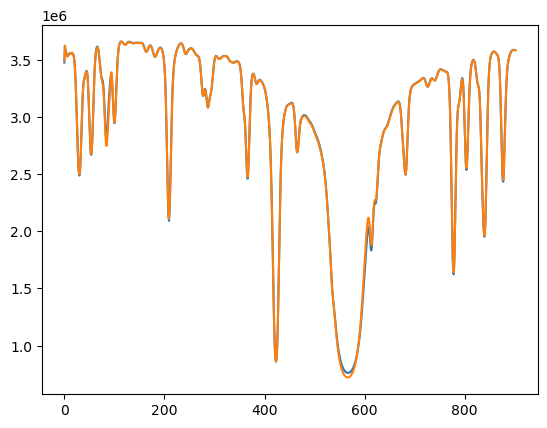

In [48]:
plt.plot(stavg1);plt.plot(stavg2)